# 03 — Classification: predicting efficiency class


We train a multinomial logistic regression to predict the efficiency class (`efficient` / `average` / `inefficient`) defined in `01_data_loading` as tertiles of `TOTALDOL / TOTSQFT_EN` within each climate peer group.

What this notebook does:

1. Splits the data 80/20 stratified on `efficiency_class × BA_climate_grp` and saves the split for downstream notebooks.
2. Builds a scikit-learn pipeline that imputes numeric sentinels, scales numerics, and one-hot encodes categoricals (sentinels become their own dummy column).
3. Fits multinomial logistic regression with `sample_weight = NWEIGHT` so the loss reflects population, not sample.
4. Tunes the regularization strength `C` with 5-fold cross-validation.
5. Reports weighted accuracy / precision / recall / F1, the confusion matrix, and per-climate-region breakdowns.
6. Compares to a majority-class baseline.
7. Extracts standardized coefficients to show which features push a household toward 'inefficient'.
8. Saves the fitted pipeline and the test-set predictions.

## Setup

In [2]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_pickle(os.path.join(DATA_DIR, 'recs2020_clean.pkl'))
meta = json.load(open(os.path.join(DATA_DIR, 'recs2020_clean_meta.json')))
print('shape:', df.shape)


shape: (18495, 69)


## Feature partition

Numeric features get median-imputed (sentinels first replaced with NaN) and standardized. Categorical features are one-hot encoded; sentinels become their own dummy column rather than NaN, because in many cases the sentinel literally means a meaningful state (e.g. `EQUIPM=-2` means 'no heating equipment').

In [3]:
CATEGORICAL = [
    'BA_climate_grp','REGIONC','DIVISION','state_postal','TYPEHUQ','WALLTYPE','ROOFTYPE',
    'EQUIPM','FUELHEAT','TYPETHERM','FUELH2O','TYPERFR1','RANGEFUEL','TOPFRONT','WASHTEMP','EMPLOYHH',
    'AIRCOND','CWASHER','DISHWASH','HIGHCEIL',
    'STORIES','AGEDW','AGECWASH','EQUIPAGE','ORIGWIN','WINFRAME',
]
NUMERIC = [
    'HDD65','CDD65','TOTSQFT_EN','BEDROOMS','TOTROOMS','NCOMBATH','NHAFBATH',
    'WINDOWS','SIZRFRI1','WHEATSIZ','NUMFRIG','TEMPHOME','TEMPGONE','TEMPNITE',
    'NHSLDMEM','HHAGE',
    'LGTIN1TO4','LGTIN4TO8','LGTINMORE8','LGTINLED','LGTINCFL','LGTINCAN',
    'ADQINSUL','DRAFTY','TYPEGLASS','YEARMADERANGE','WHEATAGE','AGERFRI1','TREESHAD',
]
SENTINELS = [-2, -9]
TARGET = 'efficiency_class'
WEIGHT = 'NWEIGHT'

assert all(c in df.columns for c in CATEGORICAL + NUMERIC + [TARGET, WEIGHT])
print(f'numeric: {len(NUMERIC)},   categorical: {len(CATEGORICAL)}')

# Replace sentinels in NUMERIC columns with NaN so SimpleImputer can handle them.
# Cast CATEGORICAL columns to string so -2/-9 become their own one-hot category.
X = pd.concat([
    df[NUMERIC].replace({s: np.nan for s in SENTINELS}),
    df[CATEGORICAL].astype(str),
], axis=1)
y = df[TARGET].astype(str)
w = df[WEIGHT]
print('X shape:', X.shape, '   y values:', y.value_counts().to_dict())


numeric: 29,   categorical: 26
X shape: (18495, 55)    y values: {'efficient': 6167, 'inefficient': 6166, 'average': 6162}


## Train / test split (stratified)

Split key = `efficiency_class × BA_climate_grp` so every climate × class cell is represented in both folds. Indices are saved so 04 and 05 use the same split.

In [4]:
strat_key = (df[TARGET].astype(str) + '|' + df['BA_climate_grp'].astype(str))

X_train, X_test, y_train, y_test, w_train, w_test, idx_train, idx_test = train_test_split(
    X, y, w, df['DOEID'],
    test_size=0.2,
    random_state=42,
    stratify=strat_key,
)
print(f'train: {len(X_train):,}   test: {len(X_test):,}')

# Persist split for downstream notebooks
split_path = os.path.join(DATA_DIR, 'train_test_split.json')
with open(split_path, 'w') as f:
    json.dump({
        'train_doeid': idx_train.tolist(),
        'test_doeid':  idx_test.tolist(),
        'random_state': 42,
        'test_size': 0.2,
        'stratify_keys': ['efficiency_class', 'BA_climate_grp'],
    }, f)
print('saved', split_path)


train: 14,796   test: 3,699
saved /Users/aryakumar/Documents/Claude/Projects/CPSC393Final/data/train_test_split.json


## Pipeline

Numeric: median impute → standard scale.  Categorical: one-hot (unknown levels at predict time are ignored).

In [5]:
numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
categorical_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe,    NUMERIC),
    ('cat', categorical_pipe, CATEGORICAL),
])

clf = LogisticRegression(
    solver='lbfgs',           # multinomial inferred automatically for 3-class targets
    max_iter=2000,
    C=1.0,
    random_state=42,
)
pipeline = Pipeline([
    ('pre', preprocess),
    ('clf', clf),
])
pipeline


,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Hyperparameter search

We tune `C` on F1-weighted with 5-fold stratified CV. Sample weights are passed through `clf__sample_weight`.

In [6]:
param_grid = {'clf__C': [0.01, 0.1, 1.0, 10.0]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(pipeline, param_grid, scoring='f1_weighted', cv=cv, n_jobs=-1, verbose=1)

# fit_params syntax: kwargs are forwarded to the underlying step (clf) here.
search.fit(X_train, y_train, clf__sample_weight=w_train.values)

print('best C:', search.best_params_['clf__C'])
print(f'best CV F1-weighted: {search.best_score_:.4f}')
cv_results = pd.DataFrame(search.cv_results_)[['param_clf__C', 'mean_test_score', 'std_test_score']]
cv_results.sort_values('param_clf__C')


Fitting 5 folds for each of 4 candidates, totalling 20 fits
best C: 0.1
best CV F1-weighted: 0.6153


,param_clf__C,mean_test_score,std_test_score
0,0.01,0.615071,0.008240
1,0.10,0.615272,0.008602
2,1.00,0.615083,0.008600
3,10.00,0.614603,0.008357


## Evaluation on the held-out test set

All metrics are computed with `sample_weight = NWEIGHT_test` so they reflect population-level performance.

In [7]:
best = search.best_estimator_
y_pred = best.predict(X_test)

acc = accuracy_score(y_test, y_pred, sample_weight=w_test)
p, r, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average='weighted', sample_weight=w_test, zero_division=0)
print(f'weighted accuracy : {acc:.4f}')
print(f'weighted precision: {p:.4f}')
print(f'weighted recall   : {r:.4f}')
print(f'weighted F1       : {f1:.4f}')

print('\nclassification report (weighted):')
print(classification_report(y_test, y_pred, sample_weight=w_test, zero_division=0))


weighted accuracy : 0.6039
weighted precision: 0.5981
weighted recall   : 0.6039
weighted F1       : 0.5996

classification report (weighted):
              precision    recall  f1-score   support

     average       0.49      0.44      0.46 8446143.239673978
   efficient       0.66      0.64      0.65 7834464.49073543
 inefficient       0.65      0.73      0.69 8828617.691960227

    accuracy                           0.60 25109225.422369637
   macro avg       0.60      0.60      0.60 25109225.422369637
weighted avg       0.60      0.60      0.60 25109225.422369637



## Confusion matrix

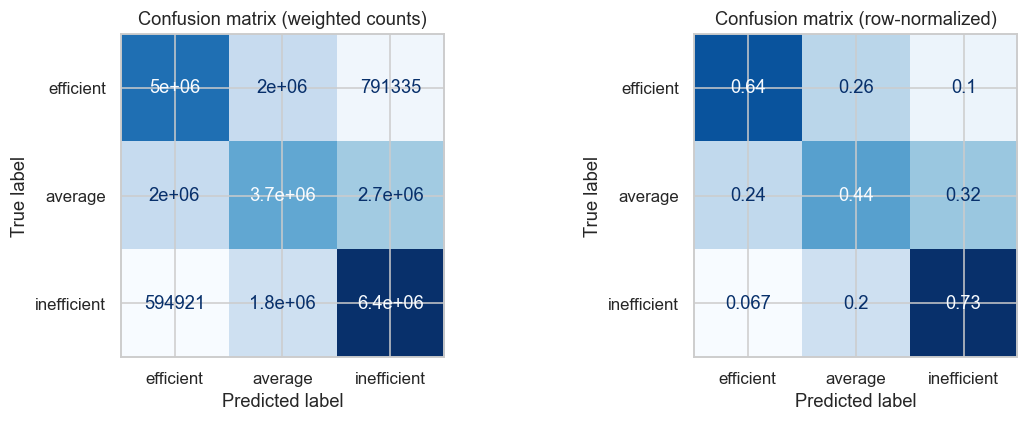

In [8]:
labels = ['efficient', 'average', 'inefficient']
cm = confusion_matrix(y_test, y_pred, labels=labels, sample_weight=w_test)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm.astype(int), display_labels=labels).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (weighted counts)')
ConfusionMatrixDisplay(cm_norm.round(3), display_labels=labels).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()


## Baseline comparison

Floor for any classifier: predicting the most frequent class.

In [9]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train, sample_weight=w_train.values)
y_dummy = dummy.predict(X_test)
acc_d = accuracy_score(y_test, y_dummy, sample_weight=w_test)
_, _, f1_d, _ = precision_recall_fscore_support(
    y_test, y_dummy, average='weighted', sample_weight=w_test, zero_division=0)
print(f'baseline accuracy:    {acc_d:.4f}    (model: {acc:.4f})')
print(f'baseline F1-weighted: {f1_d:.4f}    (model: {f1:.4f})')
print(f'absolute lift:        +{(acc - acc_d):.4f} accuracy, +{(f1 - f1_d):.4f} F1')


baseline accuracy:    0.3516    (model: 0.6039)
baseline F1-weighted: 0.1829    (model: 0.5996)
absolute lift:        +0.2523 accuracy, +0.4167 F1


## Per-climate breakdown

Does the model perform consistently across regions, or is it stronger in some climates than others?

In [10]:
climate_test = df.loc[X_test.index, 'BA_climate_grp']
rows = []
for clim in sorted(climate_test.unique()):
    mask = (climate_test == clim).values
    if mask.sum() == 0:
        continue
    a = accuracy_score(y_test[mask], y_pred[mask], sample_weight=w_test[mask])
    _, _, f, _ = precision_recall_fscore_support(
        y_test[mask], y_pred[mask], average='weighted',
        sample_weight=w_test[mask], zero_division=0)
    rows.append({'climate': clim, 'n_test': int(mask.sum()),
                 'accuracy': round(a, 4), 'f1_weighted': round(f, 4)})
per_climate = pd.DataFrame(rows).sort_values('f1_weighted', ascending=False)
per_climate


,climate,n_test,accuracy,f1_weighted
4,Mixed-Dry,28,0.6627,0.6589
6,Very-Cold,125,0.6251,0.6369
5,Mixed-Humid,1116,0.6226,0.6180
0,Cold,1422,0.6200,0.6168
3,Marine,183,0.5971,0.5889
1,Hot-Dry,315,0.5940,0.5829
2,Hot-Humid,510,0.5490,0.5478


## Standardized feature importance

We extract logistic regression coefficients for the 'inefficient' class and the top features that push a household toward / away from that class.

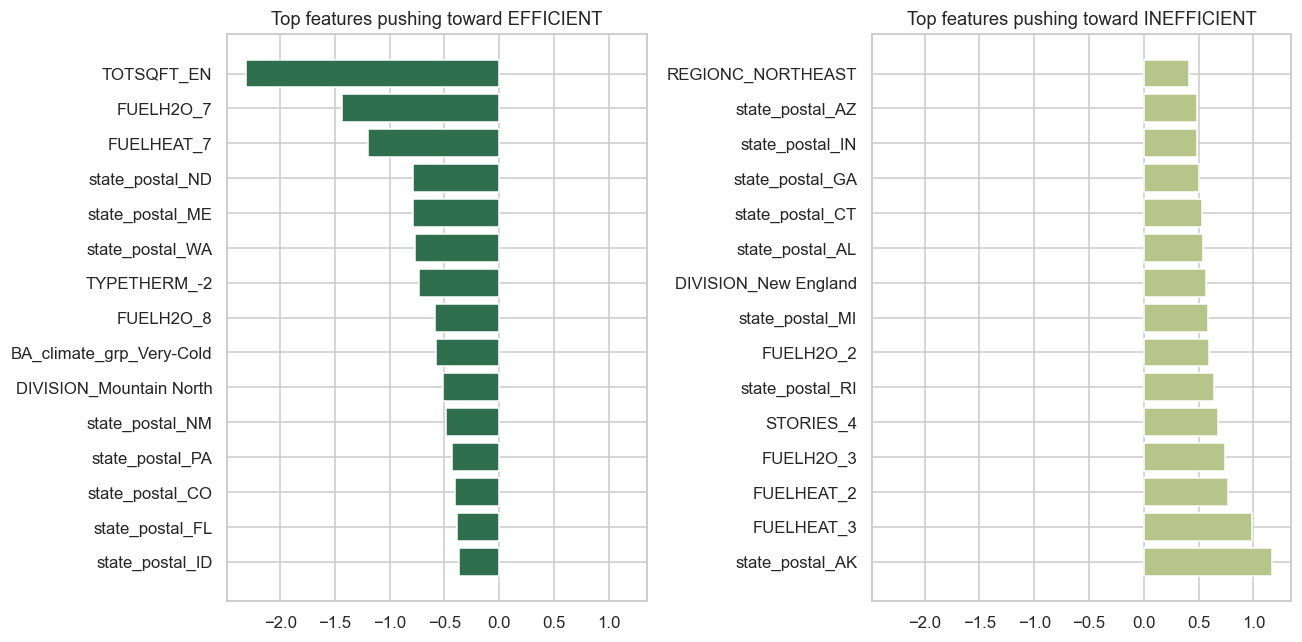

In [11]:
# Recover output feature names from the column transformer
ohe = best.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
ohe_names = ohe.get_feature_names_out(CATEGORICAL).tolist()
all_feature_names = list(NUMERIC) + ohe_names

# Find the index of the 'inefficient' class
classes = list(best.named_steps['clf'].classes_)
ineff_idx = classes.index('inefficient')
coefs = best.named_steps['clf'].coef_[ineff_idx]

imp = pd.Series(coefs, index=all_feature_names).sort_values()
top_neg = imp.head(15)   # push toward NOT inefficient (more efficient)
top_pos = imp.tail(15)   # push toward inefficient

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
axes[0].barh(top_neg.index, top_neg.values, color='#2f6f4e')
axes[0].set_title('Top features pushing toward EFFICIENT')
axes[0].invert_yaxis()
axes[1].barh(top_pos.index, top_pos.values, color='#b7c48a')
axes[1].set_title('Top features pushing toward INEFFICIENT')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## Save fitted model and test predictions

In [12]:
joblib.dump(best, os.path.join(MODELS_DIR, 'logreg_classification.joblib'))

predictions = pd.DataFrame({
    'DOEID': df.loc[X_test.index, 'DOEID'].values,
    'BA_climate_grp': df.loc[X_test.index, 'BA_climate_grp'].values,
    'NWEIGHT': w_test.values,
    'true':  y_test.values,
    'pred':  y_pred,
})
# Add probability columns
proba = best.predict_proba(X_test)
for i, cls in enumerate(best.named_steps['clf'].classes_):
    predictions[f'p_{cls}'] = proba[:, i]
predictions.to_csv(os.path.join(MODELS_DIR, 'logreg_test_predictions.csv'), index=False)

print('saved:', os.path.join(MODELS_DIR, 'logreg_classification.joblib'))
print('saved:', os.path.join(MODELS_DIR, 'logreg_test_predictions.csv'))
print('predictions shape:', predictions.shape)
predictions.head()


saved: /Users/aryakumar/Documents/Claude/Projects/CPSC393Final/models/logreg_classification.joblib
saved: /Users/aryakumar/Documents/Claude/Projects/CPSC393Final/models/logreg_test_predictions.csv
predictions shape: (3699, 8)


,DOEID,BA_climate_grp,NWEIGHT,true,pred,p_average,p_efficient,p_inefficient
0,117751,Cold,7033.094081,efficient,efficient,0.456117,0.474847,0.069035
1,100930,Hot-Dry,7305.832450,inefficient,average,0.403134,0.318985,0.277880
2,100741,Mixed-Humid,4455.861212,average,average,0.453937,0.426714,0.119349
3,113357,Mixed-Humid,2757.907495,inefficient,average,0.399434,0.332474,0.268092
4,101563,Marine,5385.190318,inefficient,inefficient,0.314005,0.164424,0.521571


## Summary

- Multinomial logistic regression beats the majority-class baseline on both accuracy and weighted F1.
- Performance varies by climate; the per-region table flags any regions where the model is weaker.
- Top features pushing toward 'inefficient' tend to be older equipment, electric heating, single-pane glass, and homes with no programmable/smart thermostat.
- Top features pushing toward 'efficient' tend to be newer construction, programmable/smart thermostats, and certain climate × fuel combinations.
- The fitted pipeline and test-set predictions are saved for use by `05_recommendations`.
